In [1]:
import os, random, copy
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## **CONFIG** 

In [2]:
DATA_DIR = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"

train_csv = os.path.join(DATA_DIR, "train.csv")
val_csv   = os.path.join(DATA_DIR, "validation.csv")
test_csv  = os.path.join(DATA_DIR, "test.csv")

BATCH_SIZE = 32
EPOCHS = 30
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## **SEED**

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

## **DATASET** 

In [4]:
class EuroSATDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.df = pd.read_csv(csv_file)

        if self.df.columns[0] == "Unnamed: 0":
            self.df = self.df.drop(columns=self.df.columns[0])

        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(self.df["ClassName"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["Filename"])
        label = self.class_to_idx[row["ClassName"]]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

## **TRANSFORM**

In [5]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

## **DATALOADER**

In [6]:
train_dataset = EuroSATDataset(train_csv, DATA_DIR, train_transform)
val_dataset   = EuroSATDataset(val_csv, DATA_DIR, val_transform)
test_dataset  = EuroSATDataset(test_csv, DATA_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(train_dataset.classes)

## **RESNET50 MODEL**

In [7]:
def create_model():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # freeze toàn bộ
    for p in model.parameters():
        p.requires_grad = False

    # unfreeze layer4
    for p in model.layer4.parameters():
        p.requires_grad = True

    # replace classifier
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model.to(DEVICE)

## **PLOT HISTORY**

In [8]:
def plot_history(history, title="Training Curve"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.show()

## **TRAIN LOOP**

In [9]:
def train_model(optimizer_name, lr):

    model = create_model()
    criterion = nn.CrossEntropyLoss()

    params = filter(lambda p: p.requires_grad, model.parameters())

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(params, lr=lr)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(params, lr=lr)
    else:
        optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.1, patience=2
    )

    best_val_acc = 0
    best_wts = copy.deepcopy(model.state_dict())

    patience = 5
    no_improve = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(EPOCHS):

        # TRAIN
        model.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for x, y in tqdm(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(out, 1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(y.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)

        # VAL
        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)

                out = model(x)
                loss = criterion(out, y)

                val_loss += loss.item()

                preds = torch.argmax(out, 1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(y.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)

        print(f"{optimizer_name} LR={lr} | Epoch {epoch+1} | "
              f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_wts)
    return model, best_val_acc, history

## **EVALUATION**

In [10]:
def evaluate_model(model):

    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(DEVICE)
            out = model(x)

            preds = torch.argmax(out, 1).cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(y.numpy())

    acc = accuracy_score(labels_all, preds_all)
    prec = precision_score(labels_all, preds_all, average="weighted")
    rec = recall_score(labels_all, preds_all, average="weighted")
    f1m = f1_score(labels_all, preds_all, average="macro")
    f1w = f1_score(labels_all, preds_all, average="weighted")

    print(classification_report(labels_all, preds_all))

    cm = confusion_matrix(labels_all, preds_all)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.show()

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_macro": f1m,
        "F1_weighted": f1w
    }

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 242MB/s]
100%|██████████| 591/591 [03:09<00:00,  3.12it/s]


Adam LR=0.001 | Epoch 1 | Train Acc=0.9224 | Val Acc=0.9704


100%|██████████| 591/591 [02:05<00:00,  4.70it/s]


Adam LR=0.001 | Epoch 2 | Train Acc=0.9613 | Val Acc=0.9731


...

Adam LR=0.001 | Epoch 23 | Train Acc=0.9981 | Val Acc=0.9807


100%|██████████| 591/591 [02:04<00:00,  4.74it/s]


Adam LR=0.001 | Epoch 24 | Train Acc=0.9987 | Val Acc=0.9811


100%|██████████| 591/591 [02:04<00:00,  4.74it/s]


Adam LR=0.001 | Epoch 25 | Train Acc=0.9985 | Val Acc=0.9809
Early stopping


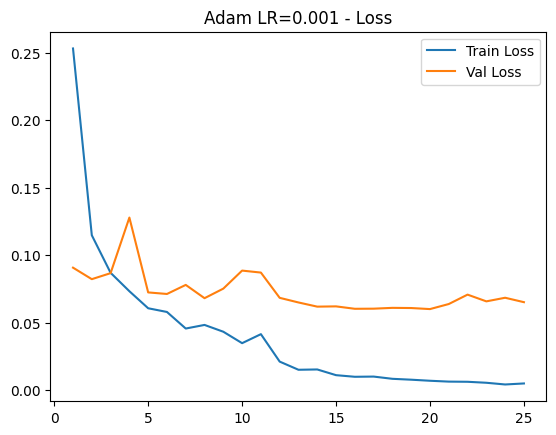

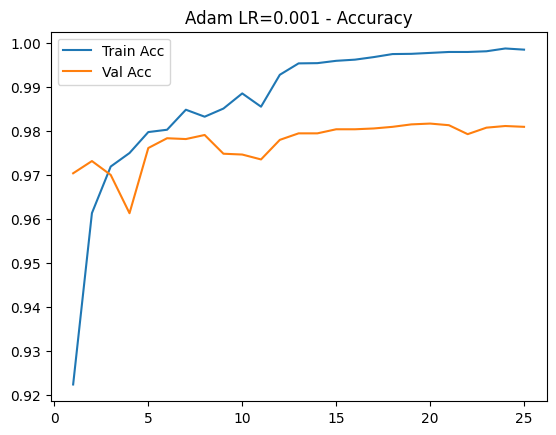

100%|██████████| 591/591 [02:05<00:00,  4.71it/s]


Adam LR=0.0001 | Epoch 1 | Train Acc=0.8793 | Val Acc=0.9563


100%|██████████| 591/591 [02:06<00:00,  4.67it/s]


Adam LR=0.0001 | Epoch 2 | Train Acc=0.9546 | Val Acc=0.9663


100%|██████████| 591/591 [02:05<00:00,  4.72it/s]


...

Adam LR=0.0001 | Epoch 11 | Train Acc=0.9903 | Val Acc=0.9800


100%|██████████| 591/591 [02:04<00:00,  4.73it/s]


Adam LR=0.0001 | Epoch 12 | Train Acc=0.9908 | Val Acc=0.9802


100%|██████████| 591/591 [02:04<00:00,  4.74it/s]


Adam LR=0.0001 | Epoch 13 | Train Acc=0.9916 | Val Acc=0.9807
Early stopping


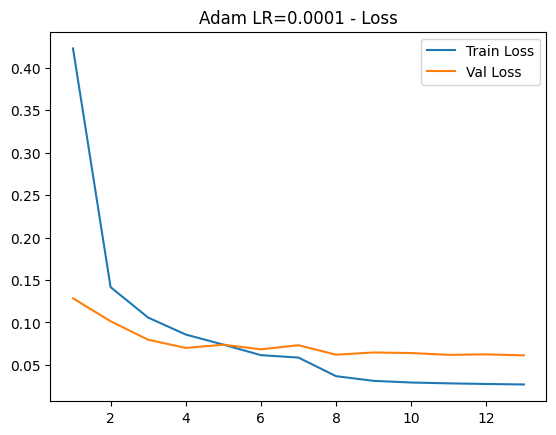

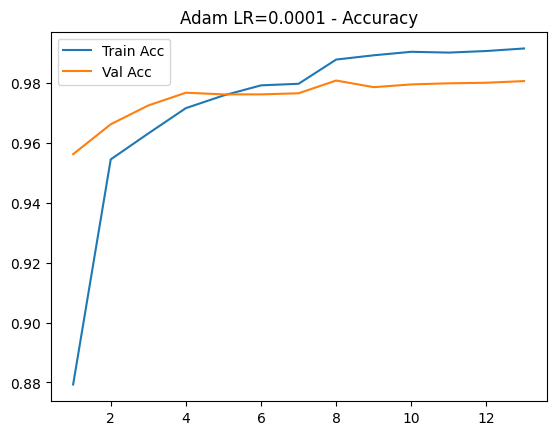

100%|██████████| 591/591 [02:04<00:00,  4.75it/s]


Adam LR=1e-05 | Epoch 1 | Train Acc=0.5814 | Val Acc=0.7922


100%|██████████| 591/591 [02:03<00:00,  4.77it/s]


Adam LR=1e-05 | Epoch 2 | Train Acc=0.8634 | Val Acc=0.9306


100%|██████████| 591/591 [02:05<00:00,  4.71it/s]


...

Adam LR=1e-05 | Epoch 18 | Train Acc=0.9702 | Val Acc=0.9726


100%|██████████| 591/591 [02:03<00:00,  4.77it/s]


Adam LR=1e-05 | Epoch 19 | Train Acc=0.9704 | Val Acc=0.9724


100%|██████████| 591/591 [02:03<00:00,  4.77it/s]


Adam LR=1e-05 | Epoch 20 | Train Acc=0.9702 | Val Acc=0.9737
Early stopping


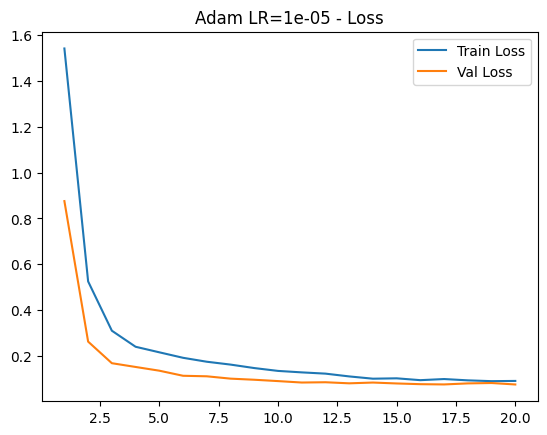

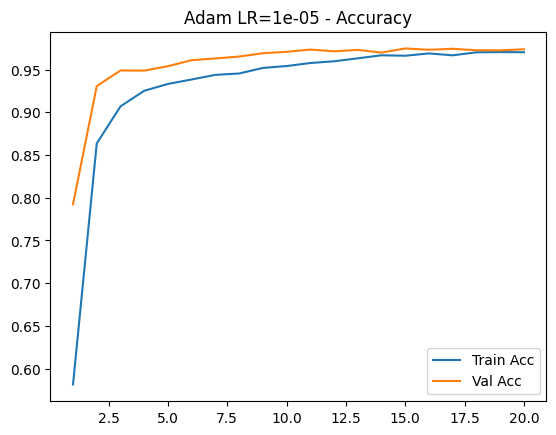


BEST Adam: LR=0.001 | Val Acc=0.9817


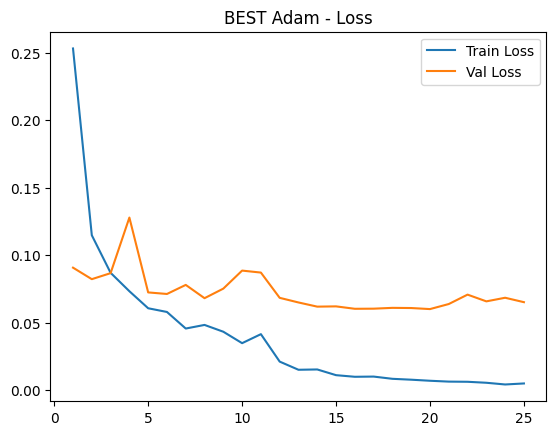

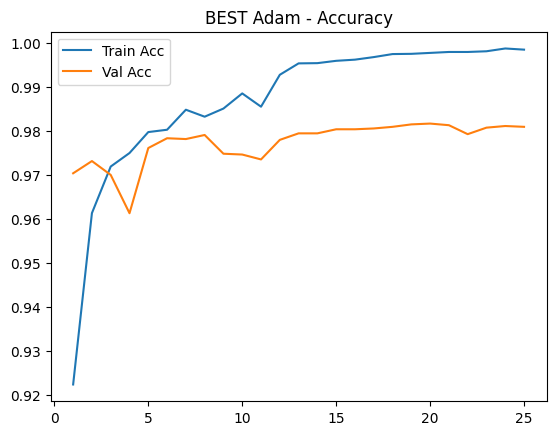

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       300
           1       1.00      1.00      1.00       300
           2       0.97      0.97      0.97       300
           3       0.98      0.98      0.98       250
           4       1.00      1.00      1.00       250
           5       0.97      0.98      0.98       200
           6       0.96      0.96      0.96       250
           7       1.00      1.00      1.00       300
           8       0.98      0.98      0.98       250
           9       1.00      1.00      1.00       300

    accuracy                           0.99      2700
   macro avg       0.98      0.99      0.98      2700
weighted avg       0.99      0.99      0.99      2700



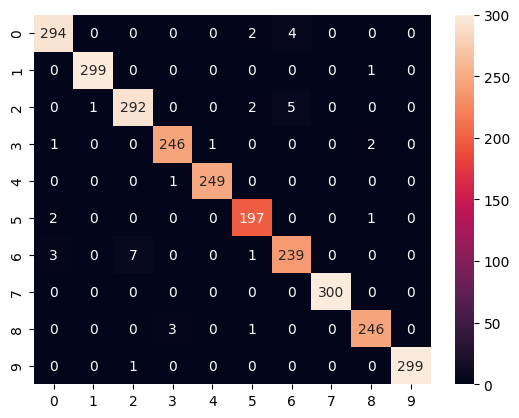

100%|██████████| 591/591 [02:07<00:00,  4.63it/s]


AdamW LR=0.001 | Epoch 1 | Train Acc=0.9209 | Val Acc=0.9674


100%|██████████| 591/591 [02:07<00:00,  4.64it/s]


AdamW LR=0.001 | Epoch 2 | Train Acc=0.9626 | Val Acc=0.9744


100%|██████████| 591/591 [02:05<00:00,  4.70it/s]


...

AdamW LR=0.001 | Epoch 18 | Train Acc=0.9971 | Val Acc=0.9850


100%|██████████| 591/591 [02:03<00:00,  4.77it/s]


AdamW LR=0.001 | Epoch 19 | Train Acc=0.9963 | Val Acc=0.9835


100%|██████████| 591/591 [02:03<00:00,  4.78it/s]


AdamW LR=0.001 | Epoch 20 | Train Acc=0.9968 | Val Acc=0.9848
Early stopping


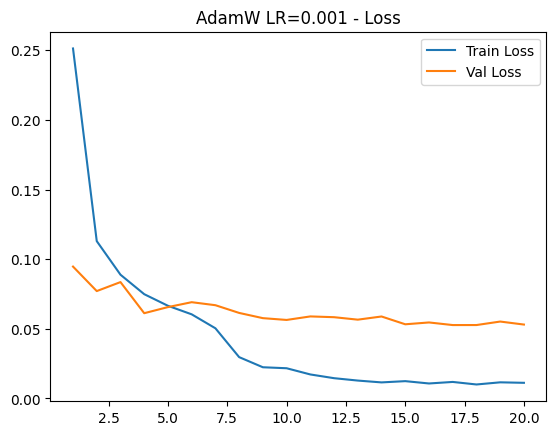

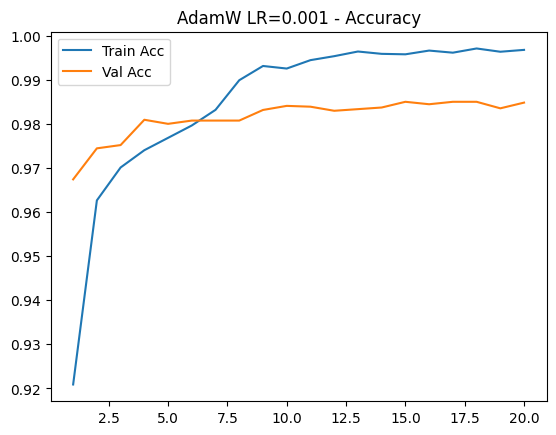

100%|██████████| 591/591 [02:03<00:00,  4.78it/s]


AdamW LR=0.0001 | Epoch 1 | Train Acc=0.8779 | Val Acc=0.9644


100%|██████████| 591/591 [02:04<00:00,  4.73it/s]


AdamW LR=0.0001 | Epoch 2 | Train Acc=0.9512 | Val Acc=0.9676


100%|██████████| 591/591 [02:03<00:00,  4.79it/s]


...

AdamW LR=0.0001 | Epoch 14 | Train Acc=0.9897 | Val Acc=0.9781


100%|██████████| 591/591 [02:08<00:00,  4.60it/s]


AdamW LR=0.0001 | Epoch 15 | Train Acc=0.9939 | Val Acc=0.9815


100%|██████████| 591/591 [02:07<00:00,  4.62it/s]


AdamW LR=0.0001 | Epoch 16 | Train Acc=0.9951 | Val Acc=0.9819
Early stopping


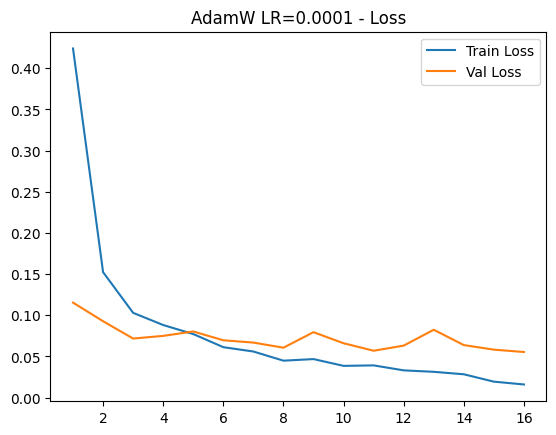

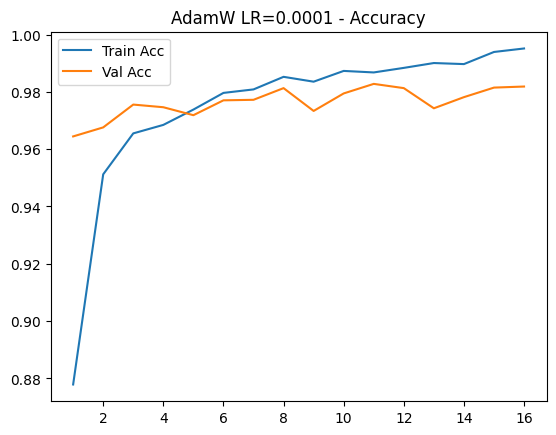

100%|██████████| 591/591 [02:12<00:00,  4.46it/s]


AdamW LR=1e-05 | Epoch 1 | Train Acc=0.6070 | Val Acc=0.8141


100%|██████████| 591/591 [02:07<00:00,  4.64it/s]


AdamW LR=1e-05 | Epoch 2 | Train Acc=0.8732 | Val Acc=0.9298


100%|██████████| 591/591 [02:07<00:00,  4.64it/s]


...

AdamW LR=1e-05 | Epoch 24 | Train Acc=0.9814 | Val Acc=0.9778


100%|██████████| 591/591 [02:04<00:00,  4.76it/s]


AdamW LR=1e-05 | Epoch 25 | Train Acc=0.9835 | Val Acc=0.9791


100%|██████████| 591/591 [02:04<00:00,  4.75it/s]


AdamW LR=1e-05 | Epoch 26 | Train Acc=0.9827 | Val Acc=0.9770
Early stopping


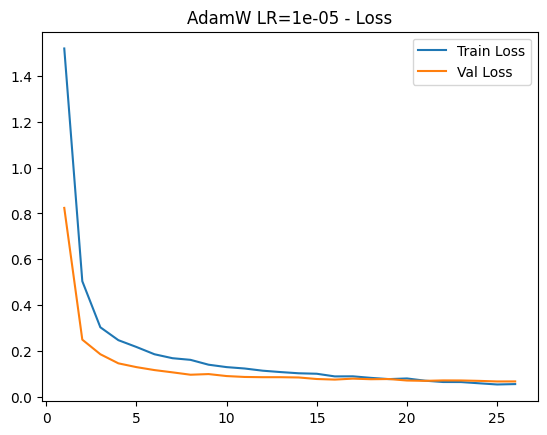

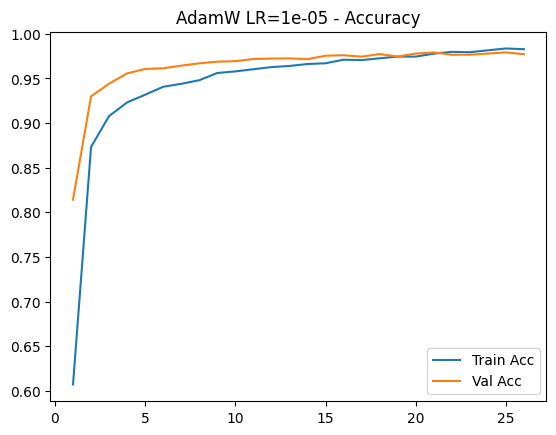


BEST AdamW: LR=0.001 | Val Acc=0.9850


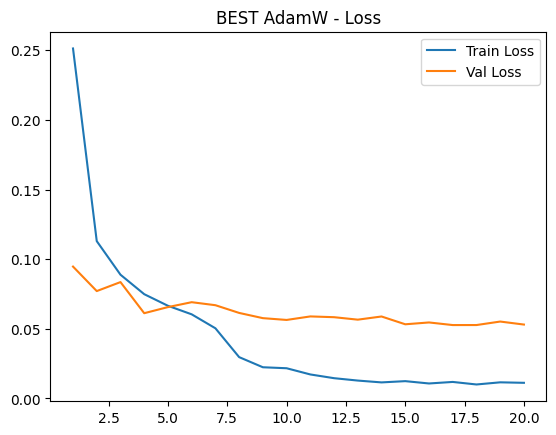

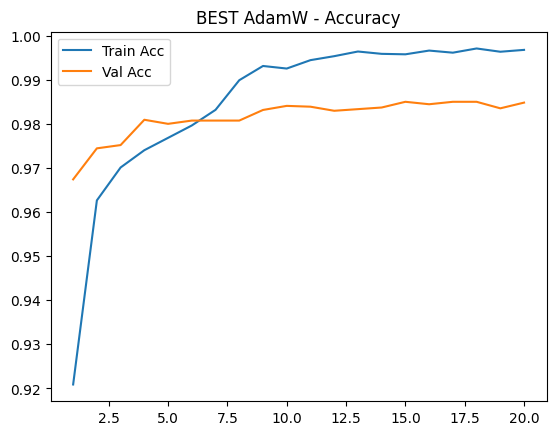

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       300
           1       1.00      0.99      0.99       300
           2       0.96      0.99      0.97       300
           3       0.98      0.99      0.99       250
           4       1.00      1.00      1.00       250
           5       0.98      0.98      0.98       200
           6       0.98      0.95      0.97       250
           7       1.00      1.00      1.00       300
           8       0.98      0.99      0.99       250
           9       1.00      0.99      1.00       300

    accuracy                           0.99      2700
   macro avg       0.99      0.99      0.99      2700
weighted avg       0.99      0.99      0.99      2700



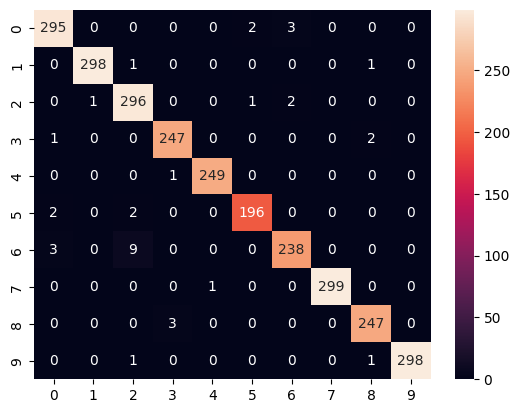

100%|██████████| 591/591 [02:02<00:00,  4.82it/s]


SGD LR=0.001 | Epoch 1 | Train Acc=0.7352 | Val Acc=0.8922


100%|██████████| 591/591 [02:02<00:00,  4.82it/s]


SGD LR=0.001 | Epoch 2 | Train Acc=0.9043 | Val Acc=0.9419


100%|██████████| 591/591 [02:02<00:00,  4.84it/s]


...

SGD LR=0.001 | Epoch 24 | Train Acc=0.9820 | Val Acc=0.9796


100%|██████████| 591/591 [02:02<00:00,  4.81it/s]


SGD LR=0.001 | Epoch 25 | Train Acc=0.9829 | Val Acc=0.9791


100%|██████████| 591/591 [02:05<00:00,  4.72it/s]


SGD LR=0.001 | Epoch 26 | Train Acc=0.9835 | Val Acc=0.9798
Early stopping


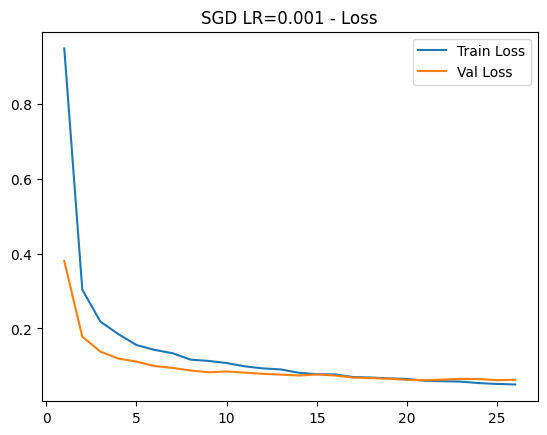

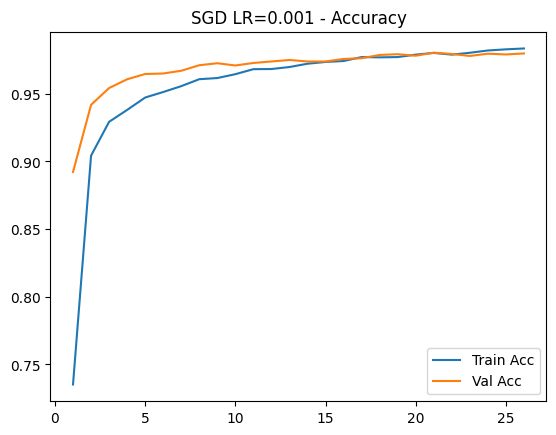

100%|██████████| 591/591 [02:04<00:00,  4.73it/s]


SGD LR=0.0001 | Epoch 1 | Train Acc=0.4057 | Val Acc=0.5520


100%|██████████| 591/591 [02:07<00:00,  4.64it/s]


SGD LR=0.0001 | Epoch 2 | Train Acc=0.6052 | Val Acc=0.6046


100%|██████████| 591/591 [02:04<00:00,  4.75it/s]


...

SGD LR=0.0001 | Epoch 28 | Train Acc=0.9347 | Val Acc=0.9526


100%|██████████| 591/591 [02:08<00:00,  4.59it/s]


SGD LR=0.0001 | Epoch 29 | Train Acc=0.9361 | Val Acc=0.9524


100%|██████████| 591/591 [02:08<00:00,  4.59it/s]


SGD LR=0.0001 | Epoch 30 | Train Acc=0.9389 | Val Acc=0.9537


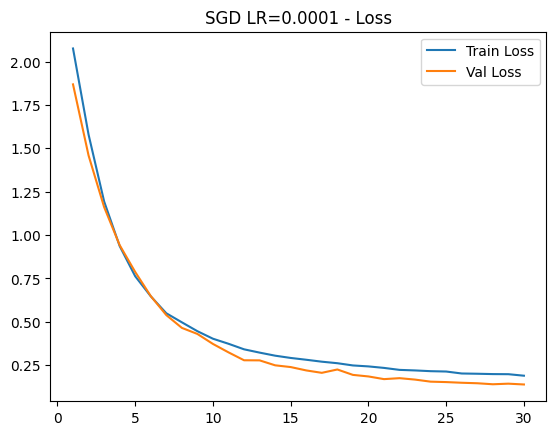

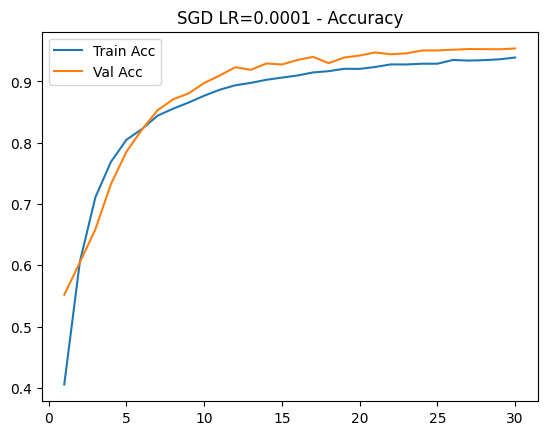

100%|██████████| 591/591 [02:06<00:00,  4.69it/s]


SGD LR=1e-05 | Epoch 1 | Train Acc=0.0961 | Val Acc=0.1574


100%|██████████| 591/591 [02:06<00:00,  4.69it/s]


SGD LR=1e-05 | Epoch 2 | Train Acc=0.2055 | Val Acc=0.2906


100%|██████████| 591/591 [02:05<00:00,  4.73it/s]


...

SGD LR=1e-05 | Epoch 28 | Train Acc=0.6558 | Val Acc=0.6220


100%|██████████| 591/591 [02:09<00:00,  4.55it/s]


SGD LR=1e-05 | Epoch 29 | Train Acc=0.6503 | Val Acc=0.6328


100%|██████████| 591/591 [02:05<00:00,  4.72it/s]


SGD LR=1e-05 | Epoch 30 | Train Acc=0.6580 | Val Acc=0.6189
Early stopping


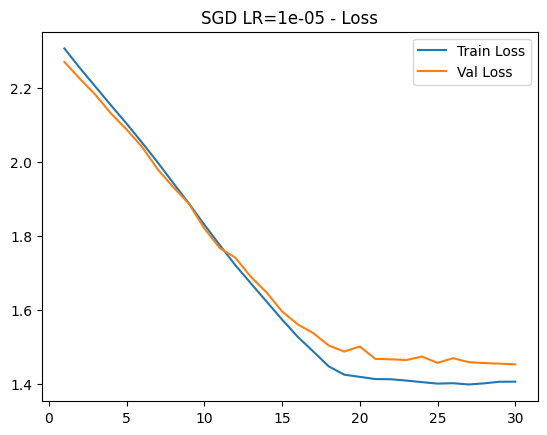

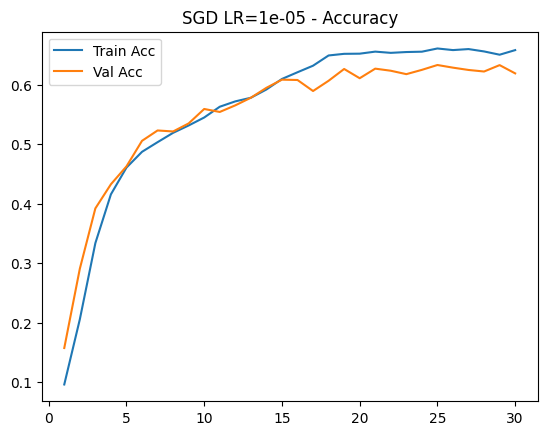


BEST SGD: LR=0.001 | Val Acc=0.9804


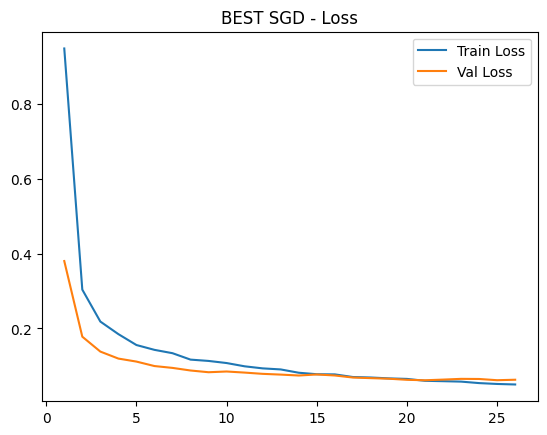

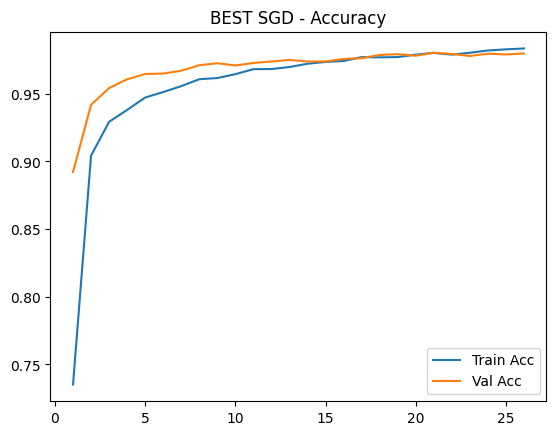

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       300
           1       0.99      0.99      0.99       300
           2       0.95      0.98      0.97       300
           3       0.98      0.98      0.98       250
           4       0.99      0.99      0.99       250
           5       0.97      0.97      0.97       200
           6       0.97      0.94      0.96       250
           7       0.99      1.00      1.00       300
           8       0.98      0.97      0.98       250
           9       1.00      1.00      1.00       300

    accuracy                           0.98      2700
   macro avg       0.98      0.98      0.98      2700
weighted avg       0.98      0.98      0.98      2700



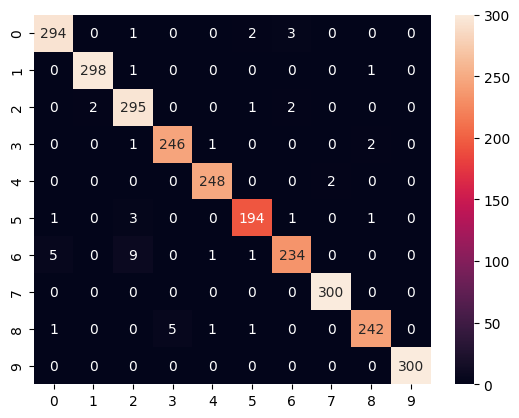

In [11]:
optimizers = ["Adam", "AdamW", "SGD"]
learning_rates = [1e-3, 1e-4, 1e-5]

results = []

global_best_acc = 0
global_best_weights = None
global_best_opt = None
global_best_lr = None

for opt in optimizers:

    best_model = None
    best_lr = None
    best_hist = None
    best_acc = 0

    for lr in learning_rates:

        model, val_acc, history = train_model(opt, lr)

        plot_history(history, f"{opt} LR={lr}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = model
            best_lr = lr
            best_hist = history

        if val_acc > global_best_acc:
            global_best_acc = val_acc
            global_best_weights = copy.deepcopy(model.state_dict())
            global_best_opt = opt
            global_best_lr = lr

    print(f"\nBEST {opt}: LR={best_lr} | Val Acc={best_acc:.4f}")

    plot_history(best_hist, f"BEST {opt}")

    metrics = evaluate_model(best_model)
    metrics["Optimizer"] = opt
    metrics["Best_LR"] = best_lr

    results.append(metrics)

   Accuracy  Precision    Recall  F1_macro  F1_weighted Optimizer  Best_LR
0  0.985556   0.985562  0.985556  0.984984     0.985553      Adam    0.001
1  0.986296   0.986396  0.986296  0.985979     0.986301     AdamW    0.001
2  0.981852   0.981930  0.981852  0.981099     0.981817       SGD    0.001
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       300
           1       1.00      0.99      0.99       300
           2       0.96      0.99      0.97       300
           3       0.98      0.99      0.99       250
           4       1.00      1.00      1.00       250
           5       0.98      0.98      0.98       200
           6       0.98      0.95      0.97       250
           7       1.00      1.00      1.00       300
           8       0.98      0.99      0.99       250
           9       1.00      0.99      1.00       300

    accuracy                           0.99      2700
   macro avg       0.99      0.99      0.99      2

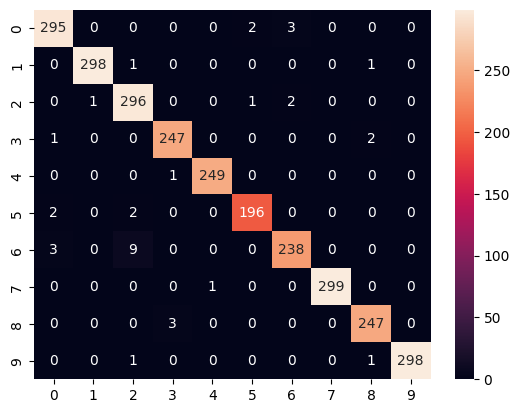

Best Opt: AdamW
Best LR: 0.001
Val Acc: 0.985
Test Acc: 0.9862962962962963


In [12]:
df = pd.DataFrame(results)
print(df)

best_model = create_model()
best_model.load_state_dict(global_best_weights)

test_metrics = evaluate_model(best_model)

print("Best Opt:", global_best_opt)
print("Best LR:", global_best_lr)
print("Val Acc:", global_best_acc)
print("Test Acc:", test_metrics["Accuracy"])

torch.save(global_best_weights, "ResNet50_EuroSAT_best.pth")